# Assignment 2: Nearest neighbours and Decision Trees on UNSW-NB15 dataset

Darren Dube
BDatSci (Statistical Learning)
Stellenbosch, South Africa
27041123@sun.ac.za

## Imports and loading of data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import utils
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

In [4]:
features_df = pd.read_csv('features.csv')
network_traffic_df = pd.read_csv('networkTraffic.csv', na_values='?')
attack_df = pd.read_csv('attack_category_map.csv')

In [5]:
RANDOM_STATE=10

## EDA (identification of data quality issues)

In [6]:
# drop unique id column
network_traffic_df = network_traffic_df.drop(columns='id')

In [7]:
network_traffic_df

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,0.000011,udp,NaN,INT,2,0,496,0,90909.090200,254,...,1,1,2,0,0,0,1,2,0,0
1,0.000008,udp,NaN,INT,2,0,1762,0,125000.000300,254,...,1,1,2,0,0,0,1,2,0,0
2,0.000005,udp,NaN,INT,2,0,1068,0,200000.005100,254,...,1,1,3,0,0,0,1,3,0,0
3,0.000006,udp,NaN,INT,2,0,900,0,166666.660800,254,...,2,1,3,0,0,0,2,3,0,0
4,0.000010,udp,NaN,INT,2,0,2126,0,100000.002500,254,...,2,1,3,0,0,0,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,24,13,24,0,0,0,24,24,0,9
257669,0.505762,tcp,NaN,FIN,10,8,620,354,33.612649,254,...,1,1,2,0,0,0,1,1,0,8
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,3,13,0,0,0,3,12,0,9
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,30,14,30,0,0,0,30,30,0,9


In [8]:
# store lists of numerical and categorical features

# fix issues in features_df
features_df.columns = features_df.columns.str.strip()
features_df['Name'] = features_df['Name'].str.lower()

is_numeric = lambda col: features_df[features_df['Name'] == col]['Type'].values in ['Float', 'Integer', 'integer']
numeric = [col for col in network_traffic_df.columns if is_numeric(col) and col != 'attack_cat'] + ['rate']
categorical = [col for col in network_traffic_df.columns if col not in numeric and col != 'attack_cat' and col != 'rate'] # TODO: figure out what rate is and where it should call

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_9579/3836798624.py:7: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  is_numeric = lambda col: features_df[features_df['Name'] == col]['Type'].values in ['Float', 'Integer', 'integer']


In [9]:
# look through DQRs for numerical and categorical features and reassign some numerical features to categorical
# NOTE: after looking at the descriptions of the numeric features with low cardinality, they all seem
#  to be indeed numeric; could alternatively create a separate "ordinal" category, but will leave unchagned for now
print(utils.continuous_dqr(network_traffic_df[numeric]))
wrongly_numeric = []

              Feature   Count  % Miss.   Card.  Min.      1st Qrt.  \
0                 dur  257673      0.0  109945   0.0      0.000008   
1               spkts  257673      0.0     646   1.0      2.000000   
2               dpkts  257673      0.0     627   0.0      0.000000   
3              sbytes  257673      0.0    9382  24.0    114.000000   
4              dbytes  257673      0.0    8653   0.0      0.000000   
5                sttl  257673      0.0      13   0.0     62.000000   
6                dttl  257673      0.0       9   0.0      0.000000   
7               sload  257673      0.0  121356   0.0  12318.004880   
8               dload  257673      0.0  116380   0.0      0.000000   
9               sloss  257673      0.0     490   0.0      0.000000   
10              dloss  257673      0.0     476   0.0      0.000000   
11             sinpkt  257673      0.0  114318   0.0      0.008000   
12             dinpkt  257673      0.0  110270   0.0      0.000000   
13               sji

In [10]:
utils.categorical_dqr(network_traffic_df[categorical])

,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
0,proto,257673,0.000000,133,tcp,123041,47.750831,udp,92701,35.976218
1,service,257673,54.845094,12,dns,68661,26.646564,http,27011,10.482666
2,state,257673,0.000000,11,FIN,117164,45.470034,INT,116438,45.188281
3,is_ftp_login,257673,0.000000,4,0,254428,98.740652,1,3219,1.249258
4,is_sm_ips_ports,257673,0.000000,2,0,253995,98.572609,1,3678,1.427391


In [11]:
# number of missing values for 'service' descriptive feature
network_traffic_df['service'].isna().sum()

141321

Text(0.5, 1.0, 'Correlation Heatmap of top 12 correlated features')

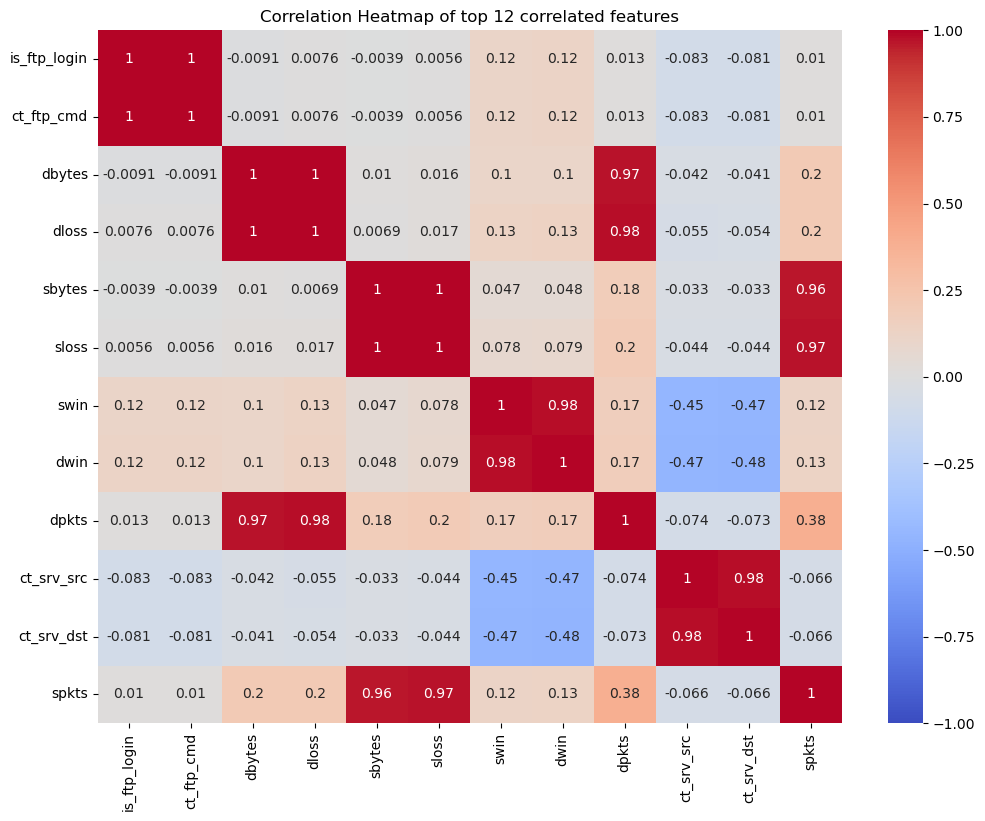

In [12]:
# compute correlation matrix for numerical features
corr_matrix = network_traffic_df.select_dtypes(include=["number"]).corr()
abs_corr = corr_matrix.abs()
top_features = (corr_matrix.abs() - np.eye(corr_matrix.shape[0])).max().nlargest(12).index
corr_matrix = corr_matrix.loc[top_features, top_features]
plt.figure(figsize=(12,9))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of top 12 correlated features')

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_9579/4090339572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')


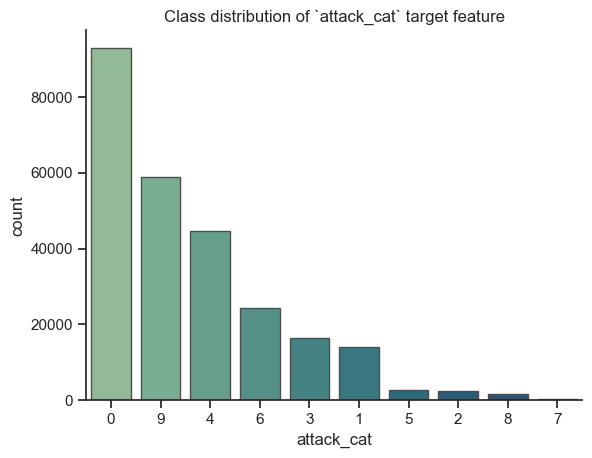

In [13]:
# class distribution of target feature
sns.set_theme(style='ticks')
order = network_traffic_df['attack_cat'].value_counts().index
ax = sns.countplot(data=network_traffic_df, x='attack_cat', order=order, palette='crest', edgecolor="0.3").set_title('Class distribution of `attack_cat` target feature')
sns.despine()

In [14]:
# outlier detection
# TODO: create a list of categorical features vs numerical (some categorical features are coded as numbers!)
count, count1 = 0, 0
for feature in network_traffic_df[numeric]:
    q1, q3 = network_traffic_df[feature].quantile([0.25, 0.75])
    outliers = network_traffic_df[(network_traffic_df[feature] < q1 - 1.5 * (q3 - q1)) | (network_traffic_df[feature] > q3 + 1.5 * (q3 - q1))]
    count1 += 1
    if not outliers.empty:
        print(f"Feature '{feature}' has {len(outliers)} outliers")
        count += 1


Feature 'dur' has 21597 outliers
Feature 'spkts' has 34871 outliers
Feature 'dpkts' has 29737 outliers
Feature 'sbytes' has 32164 outliers
Feature 'dbytes' has 40024 outliers
Feature 'sload' has 22034 outliers
Feature 'dload' has 57556 outliers
Feature 'sloss' has 16966 outliers
Feature 'dloss' has 39660 outliers
Feature 'sinpkt' has 20319 outliers
Feature 'dinpkt' has 17588 outliers
Feature 'sjit' has 23533 outliers
Feature 'djit' has 29010 outliers
Feature 'tcprtt' has 12442 outliers
Feature 'synack' has 21327 outliers
Feature 'ackdat' has 8557 outliers
Feature 'smean' has 32653 outliers
Feature 'dmean' has 33189 outliers
Feature 'trans_depth' has 25422 outliers
Feature 'response_body_len' has 16951 outliers
Feature 'ct_srv_src' has 28068 outliers
Feature 'ct_state_ttl' has 3763 outliers
Feature 'ct_dst_ltm' has 42388 outliers
Feature 'ct_src_dport_ltm' has 49014 outliers
Feature 'ct_dst_sport_ltm' has 48244 outliers
Feature 'ct_dst_src_ltm' has 43419 outliers
Feature 'ct_ftp_cmd' ha

In [15]:
len(categorical)

5

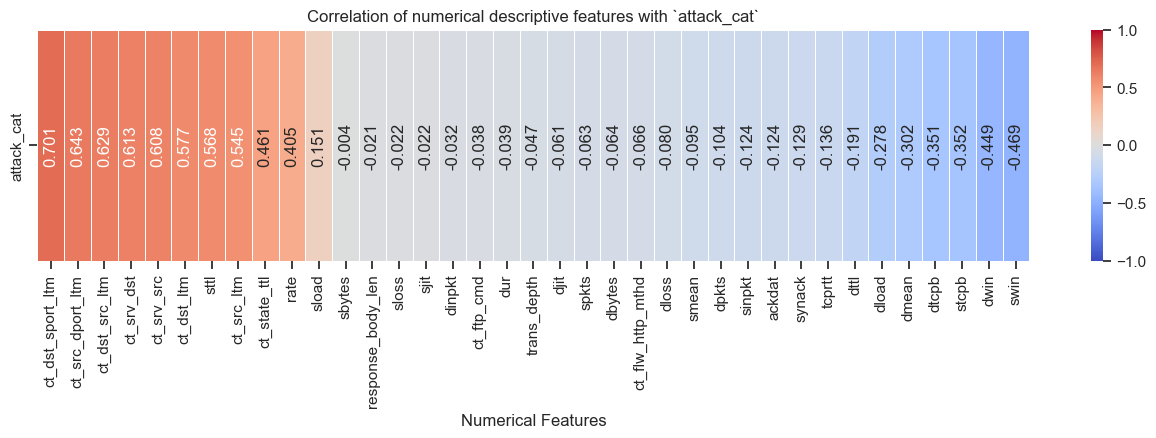

In [16]:
# detection of noise features by plotting correlation of each feature with the target
corr_matrix = network_traffic_df[numeric+['attack_cat']].corr()
target_corr = corr_matrix['attack_cat'].drop('attack_cat').sort_values(ascending=False).to_frame()

plt.figure(figsize=(16, 3))
ax = sns.heatmap(
    target_corr.T,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt=".3f",
    linewidths=0.5,
)
for text in ax.texts: text.set_rotation(90)
plt.title('Correlation of numerical descriptive features with `attack_cat`')
plt.xlabel('Numerical Features')
plt.show()


## Data Preprocessing

In [17]:
# 1. drop the id feature from the dataset -> already done

In [18]:
# 2. handling the `service` descriptive feature which has 54.8% missing values
from scipy.stats import chi2_contingency
is_missing = network_traffic_df['service'].isna().astype(int)
cont_table = pd.crosstab(is_missing, network_traffic_df['attack_cat'])
missing_rates = is_missing.groupby(network_traffic_df['attack_cat']).mean().sort_values(ascending=False)
chi2, p, df, _ = chi2_contingency(cont_table)
print(p)

# verdict: drop service column, put service_missing indicator in its place
network_traffic_df['service_missing'] = network_traffic_df['service'].isna().astype(int)
network_traffic_df = network_traffic_df.drop(columns=['service'])

0.0


In [19]:
# 3. for highly correlated feature pairs: drop 1 feature for knn, leave unchanges for decision_trees
df_dt = network_traffic_df.copy()
df_knn =network_traffic_df.copy()

corr = df_knn[numeric].corr().abs()
corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # only need upper triangle
threshold=0.95
high_corr_pairs = [
    (col, row, corr.loc[row, col]) for col in corr.columns for row in corr.index
    if pd.notna(corr.loc[row, col]) and corr.loc[row, col] > threshold
]
print(high_corr_pairs)
features_to_drop_knn = ['sbytes', 'dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_src']
numeric = [col for col in numeric if col not in features_to_drop_knn] # update numeric cols record
df_knn = df_knn.drop(columns=features_to_drop_knn)

[('sbytes', 'spkts', 0.9643932171558757), ('dbytes', 'dpkts', 0.9734453279792993), ('sloss', 'spkts', 0.9718594116511157), ('sloss', 'sbytes', 0.9957715772406861), ('dloss', 'dpkts', 0.9796120849360008), ('dloss', 'dbytes', 0.996711133831471), ('dwin', 'swin', 0.9804584289136614), ('ct_src_dport_ltm', 'ct_dst_ltm', 0.9615176986568874), ('ct_dst_src_ltm', 'ct_srv_src', 0.9539519771685916), ('ct_srv_dst', 'ct_srv_src', 0.9794668130725326), ('ct_srv_dst', 'ct_dst_src_ltm', 0.9603212131063981)]


In [20]:
# 4. oversampling minority classes to deal with feature skew class distribution
# get attack_cat counts
print(df_knn['attack_cat'].value_counts().sort_values(ascending=False))
from imblearn.over_sampling import SMOTENC

# cap the amount of resampling performed to 5 times the original count
multiplier = 5
sampling_strategy = {
    5: min(2677 * multiplier, 15000),
    2: min(2329 * multiplier, 15000),
    8: min(1511 * multiplier, 15000),
    7: min(174 * multiplier, 15000),
}
# SMOTE-NC is implemented as a step in the model pipeline in a later cell

attack_cat
0    93000
9    58871
4    44525
6    24246
3    16353
1    13987
5     2677
2     2329
8     1511
7      174
Name: count, dtype: int64


In [21]:
# 5.  handling of outliers -> decided not to handle this issue

In [22]:
# 6. handling feature range differences -> RobustScaler for k-NN, nothing for classification tree
# TODO: must also be done on training fold (create a preprocessing pipeline long term to make this easier
scaler = RobustScaler()
df_knn[numeric] = scaler.fit_transform(df_knn[numeric])

In [23]:
# 7. handling high dimensionality -> do nothing for both

In [24]:
# 8. detecting and handling noise features
print(pd.Series(mutual_info_classif(df_knn[numeric], df_knn['attack_cat'], random_state=RANDOM_STATE), index=numeric).sort_values(ascending=True))

ct_ftp_cmd           0.008793
trans_depth          0.034395
ct_flw_http_mthd     0.038626
response_body_len    0.071141
dtcpb                0.209393
swin                 0.212775
stcpb                0.216351
ct_src_ltm           0.314322
djit                 0.333359
spkts                0.347627
ackdat               0.355768
sjit                 0.358832
tcprtt               0.370521
synack               0.372243
ct_dst_ltm           0.379809
sinpkt               0.404715
sttl                 0.409450
dpkts                0.425376
dinpkt               0.439234
dttl                 0.443116
dload                0.444969
ct_srv_dst           0.446335
ct_state_ttl         0.462709
ct_dst_sport_ltm     0.474980
dur                  0.485457
rate                 0.497583
dmean                0.506077
sload                0.860960
smean                0.884490
dtype: float64


In [25]:
# 9. dealing with nominal features: leave unchanged for k-NN (use gower's metric instead), one-hot encode for classification trees
# this is done in a later cell as a step in the pipeline

In [26]:
# 10. dealing with skewed continuous distributions -> do nothing (mostly handled by what's been done above

## Model

In [27]:
NUM_FOLDS = 5

In [28]:
X_knn, y_knn = df_knn.drop(columns=['attack_cat']), df_knn['attack_cat']

In [26]:
# knn pipeline (manual k-fold cv loop to account for gowers metric calculation which cannot sit in a pipeline
import gower
from scipy.sparse import csr_matrix
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from tempfile import mkdtemp
from shutil import rmtree
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

X_knn, y_knn = df_knn.drop(columns=['attack_cat']), df_knn['attack_cat']
nominal_cols_knn = [col for col in (categorical+['service_missing']) if col in X_knn.columns]
nom_idx_knn = [X_knn.columns.get_loc(col) for col in (categorical+['service_missing']) if col in X_knn.columns]
X_knn_sample, _, y_knn_sample, _ = train_test_split(
    df_knn.drop(columns=['attack_cat']),
    df_knn['attack_cat'],
    train_size=50000,
    stratify=df_knn['attack_cat'],
    random_state=RANDOM_STATE
)
k=5 # TODO: knn hyperparameter to be tuned
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_idx_knn)
    ],
    remainder='passthrough'
)
cache_dir = mkdtemp()

knn_pipeline = Pipeline(steps=[
    ('smote', SMOTENC(categorical_features=nom_idx_knn, sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)),
    ('preprocess', preprocessor_knn),
    ('classifier', KNeighborsClassifier(
        metric='manhattan',
        algorithm='auto',
        n_jobs=-1
    ))
], memory=cache_dir)


fold_results = []

k_values_grid = [9]
param_grid = {'classifier__n_neighbors': k_values_grid}
fold_metrics = {k: [] for k in k_values_grid}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=1,
    verbose=3
)

print("Starting KNN GridSearch with OHE...")
grid_search_knn.fit(X_knn_sample, y_knn)

print("Best k:", grid_search_knn.best_params_)
print("Best CV F1 Score:", grid_search_knn.best_score_)

rmtree(cache_dir)

Starting KNN GridSearch with OHE...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END .........classifier__n_neighbors=9;, score=0.500 total time= 4.1min
[CV 2/5] END .........classifier__n_neighbors=9;, score=0.500 total time= 5.0min
[CV 3/5] END .........classifier__n_neighbors=9;, score=0.510 total time= 4.8min
[CV 4/5] END .........classifier__n_neighbors=9;, score=0.505 total time= 4.9min
[CV 5/5] END .........classifier__n_neighbors=9;, score=0.508 total time= 4.6min
Best k: {'classifier__n_neighbors': 9}
Best CV F1 Score: 0.5047076246277327


In [29]:
from sklearn.model_selection import cross_val_predict
x = grid_search_knn.best_estimator_
all_y_pred_knn = cross_val_predict(x, X_knn, y_knn, cv=5, n_jobs=1)
cr_knn = classification_report(y_knn, all_y_pred_knn, digits=4)
cm_knn = confusion_matrix(y_knn, all_y_pred_knn)
pd.DataFrame(cr_knn).to_csv('knn_report.csv')
pd.DataFrame(cm_knn).to_csv('cm_knn.csv')

KeyboardInterrupt: 

In [31]:
from sklearn.model_selection import train_test_split
import joblib
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, stratify=y_knn, random_state=RANDOM_STATE
)
x = joblib.load('best_knn_model.pkl')
print('got here')
x.fit(X_train_knn, y_train_knn)
print('got here 2')
y_pred_knn = x.predict(X_test_knn)
print('got here 3')
report_dict = classification_report(y_test_knn, y_pred_knn, digits=4, output_dict=True)
pd.DataFrame(report_dict).transpose().to_csv('knn_classification_report.csv')

cm_knn = confusion_matrix(y_test_knn, y_pred_knn)
pd.DataFrame(cm_knn).to_csv('cm_knn.csv')

got here
got here 2
got here 3


In [32]:
cm_knn

array([[16888,   185,     9,     7,   103,   156,  1031,     6,   213,
            2],
       [   55,  2011,    14,   199,   461,     3,     7,     3,    44,
            1],
       [   10,     3,    35,   150,   233,     0,    29,     0,     6,
            0],
       [   77,    42,    17,  1073,  1924,    14,    68,     2,    51,
            3],
       [  363,   229,    77,  1435,  6370,    39,   202,    60,   114,
           16],
       [   47,     0,     7,   144,   229,    75,    33,     0,     0,
            0],
       [ 1677,   134,    49,   163,   397,     2,  2250,    12,   159,
            6],
       [    0,     4,     0,     0,    18,     0,     0,    12,     1,
            0],
       [   47,    25,     2,     0,     2,     0,    20,     0,   206,
            0],
       [   34,     7,     1,    45,   171,     1,    16,     2,    10,
        11487]])

In [43]:
# classification tree pipeline
from imblearn.pipeline import Pipeline
from tempfile import mkdtemp
from shutil import rmtree
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
cache_dir = mkdtemp()
X_dt, y_dt = df_dt.drop(columns=['attack_cat']), df_dt['attack_cat']

nominal_cols_dt = categorical + ['service_missing']
nom_idx_dt = [X_dt.columns.get_loc(col) for col in nominal_cols_dt if col in X_dt.columns]

outer_cv = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_STATE)

preprocessor_dt = ColumnTransformer(
    transformers=[('onehotencode', OneHotEncoder(handle_unknown='ignore'), nom_idx_dt)],
    remainder='passthrough'
)

smotenc_dt = SMOTENC(categorical_features=nom_idx_dt, sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
alpha = 0.0 # TODO: a hyperparam to be tuned

# run data through pipeline to get cost complexity pruning path
X_tmp, y_tmp = smotenc_dt.fit_resample(X_dt, y_dt)
X_tmp = preprocessor_dt.fit_transform(X_tmp)
tree_tmp = DecisionTreeClassifier(random_state=RANDOM_STATE)
ccp_alphas = tree_tmp.cost_complexity_pruning_path(X_tmp, y_tmp).ccp_alphas[:-1]
ccp_alphas = np.maximum(ccp_alphas, 0.0)
sampled_alphas = np.linspace(ccp_alphas.min(), ccp_alphas.max(), num=5)

alpha_param_grid = {
    'classifier__ccp_alpha': sampled_alphas
}
dt_pipeline = Pipeline(steps=[
    ('smote', smotenc_dt),
    ('preprocess', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha))
], memory=cache_dir)

grid_search = GridSearchCV(estimator=dt_pipeline, param_grid=alpha_param_grid, cv=NUM_FOLDS, scoring='f1_macro', n_jobs=-1, verbose=3)

grid_search.fit(X_dt, y_dt)
print(grid_search.best_params_)
print(grid_search.best_score_)
best_dt_model = grid_search.best_estimator_
rmtree(cache_dir)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 5/5] END .........classifier__ccp_alpha=0.0;, score=0.494 total time= 1.8min
[CV 2/5] END .........classifier__ccp_alpha=0.0;, score=0.451 total time= 1.8min
[CV 2/5] END classifier__ccp_alpha=0.029374123964086007;, score=0.133 total time= 1.8min
[CV 1/5] END .........classifier__ccp_alpha=0.0;, score=0.513 total time= 1.9min
[CV 4/5] END .........classifier__ccp_alpha=0.0;, score=0.558 total time= 1.9min
[CV 1/5] END classifier__ccp_alpha=0.029374123964086007;, score=0.224 total time= 1.9min
[CV 3/5] END .........classifier__ccp_alpha=0.0;, score=0.558 total time= 1.9min
[CV 3/5] END classifier__ccp_alpha=0.029374123964086007;, score=0.215 total time= 2.0min
[CV 5/5] END classifier__ccp_alpha=0.029374123964086007;, score=0.184 total time= 1.3min
[CV 2/5] END classifier__ccp_alpha=0.058748247928172015;, score=0.133 total time= 1.2min
[CV 5/5] END classifier__ccp_alpha=0.058748247928172015;, score=0.184 total time= 1.2min
[

In [44]:
from sklearn.model_selection import cross_val_predict
all_y_pred_dt = cross_val_predict(best_dt_model, X_dt, y_dt, cv=5, n_jobs=1)
classification_report(y_dt, all_y_pred_dt, digits=4)


'              precision    recall  f1-score   support\n\n           0     0.8859    0.8495    0.8673     93000\n           1     0.8792    0.7542    0.8119     13987\n           2     0.0410    0.1421    0.0636      2329\n           3     0.2748    0.2662    0.2704     16353\n           4     0.7116    0.5865    0.6430     44525\n           5     0.0585    0.1576    0.0853      2677\n           6     0.4866    0.4801    0.4833     24246\n           7     0.3170    0.5575    0.4042       174\n           8     0.4192    0.6592    0.5125      1511\n           9     0.9324    0.9830    0.9571     58871\n\n    accuracy                         0.7427    257673\n   macro avg     0.5006    0.5436    0.5099    257673\nweighted avg     0.7703    0.7427    0.7543    257673\n'

In [48]:
x = classification_report(y_dt, all_y_pred_dt, digits=4, output_dict=True)

In [50]:
pd.DataFrame(x).to_csv('dt_report.csv')

In [52]:
cm_array = confusion_matrix(y_dt, all_y_pred_dt)

In [55]:
pd.DataFrame(cm_array).to_csv('dt_cm.csv')